In [27]:
# Merging DataFrames
import pandas as pd


In [28]:
food = pd.read_csv("Restaurant - Foods.csv")
customers = pd.read_csv("Restaurant - Customers.csv")
week1 = pd.read_csv("Restaurant - Week 1 Sales.csv")
week2 = pd.read_csv("Restaurant - Week 2 Sales.csv")

In [5]:
week2.head()

,Customer ID,Food ID
0,688,10
1,813,7
2,495,10
3,189,5
4,267,3


In [6]:
len(week1)

250

In [7]:
len(week2)

250

In [12]:
pd.concat([week1,week2])
pd.concat([week1,week2], ignore_index=False).sort_index()

# crea 500 numeros consecutivos
#pd.concat([week1,week2], ignore_index=True)

,Customer ID,Food ID
0,537,9
0,688,10
1,97,4
1,813,7
2,658,1
...,...,...
247,134,3
248,252,9
248,396,6
249,535,10


In [14]:
pd.concat([week1,week2], keys=["Week 1", "Week 2"]).sort_index()

Customer ID  Food ID
Week 1 0            537        9
       1             97        4
       2            658        1
       3            202        2
       4            155        9
...                 ...      ...
Week 2 245          783       10
       246          556       10
       247          547        9
       248          252        9
       249          249        6

[500 rows x 2 columns]

In [ ]:
df1 = pd.DataFrame([1,2,3], columns=["A"])
df2 = pd.DataFrame([4,5,6], columns=["B"])

pd.concat([df1,df2], axis="index")

pd.concat([df1,df2], axis="columns")

,A,B
0,1,4
1,2,5
2,3,6


In [18]:
pd.concat([week1,week2], axis = "columns").sort_index()

,Customer ID,Food ID,Customer ID,Food ID
0,537,9,688,10
1,97,4,813,7
2,658,1,495,10
3,202,2,189,5
4,155,9,267,3
...,...,...,...,...
245,413,9,783,10
246,926,6,556,10
247,134,3,547,9
248,396,6,252,9


In [4]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [5]:
food.head(5)

,Food ID,Food Item,Price
0,1,Sushi,3.99
1,2,Burrito,9.99
2,3,Taco,2.99
3,4,Quesadilla,4.25
4,5,Pizza,2.49


In [6]:
week1.merge(food, how="left", on="Food ID")

,Customer ID,Food ID,Food Item,Price
0,537,9,Donut,0.99
1,97,4,Quesadilla,4.25
2,658,1,Sushi,3.99
3,202,2,Burrito,9.99
4,155,9,Donut,0.99
...,...,...,...,...
245,413,9,Donut,0.99
246,926,6,Pasta,13.99
247,134,3,Taco,2.99
248,396,6,Pasta,13.99


In [8]:
week1.merge(food, how="right", on="Food ID").sort_index()

,Customer ID,Food ID,Food Item,Price
0,658,1,Sushi,3.99
1,600,1,Sushi,3.99
2,155,1,Sushi,3.99
3,341,1,Sushi,3.99
4,20,1,Sushi,3.99
...,...,...,...,...
245,809,10,Drink,1.75
246,584,10,Drink,1.75
247,274,10,Drink,1.75
248,151,10,Drink,1.75


In [9]:
week1.merge(food, how="inner", on="Food ID")

,Customer ID,Food ID,Food Item,Price
0,537,9,Donut,0.99
1,155,9,Donut,0.99
2,961,9,Donut,0.99
3,147,9,Donut,0.99
4,680,9,Donut,0.99
...,...,...,...,...
245,809,10,Drink,1.75
246,584,10,Drink,1.75
247,274,10,Drink,1.75
248,151,10,Drink,1.75


In [11]:
week1.merge(food, how="outer", on="Food ID")

,Customer ID,Food ID,Food Item,Price
0,537,9,Donut,0.99
1,155,9,Donut,0.99
2,961,9,Donut,0.99
3,147,9,Donut,0.99
4,680,9,Donut,0.99
...,...,...,...,...
245,809,10,Drink,1.75
246,584,10,Drink,1.75
247,274,10,Drink,1.75
248,151,10,Drink,1.75


In [12]:
week1.merge(food, how="cross", on="Food ID")

MergeError: Can not pass on, right_on, left_on or set right_index=True or left_index=True

In [13]:
week2.merge(customers, how="left", left_on="Customer ID", right_on="ID")

,Customer ID,Food ID,ID,First Name,Last Name,Gender,Company,Occupation
0,688,10,688,Carl,Williamson,Male,Thoughtmix,Graphic Designer
1,813,7,813,Johnny,Walker,Male,Kayveo,Developer II
2,495,10,495,Deborah,Little,Female,Babbleblab,VP Accounting
3,189,5,189,Roger,Gordon,Male,Skilith,Operator
4,267,3,267,Matthew,Wood,Male,Agimba,Product Engineer
...,...,...,...,...,...,...,...,...
245,783,10,783,Phyllis,Meyer,Female,Voolia,Information Systems Manager
246,556,10,556,Samuel,Bailey,Male,Oyoloo,Nurse
247,547,9,547,Tina,Watkins,Female,Thoughtstorm,Accountant II
248,252,9,252,Douglas,Powell,Male,Jetwire,Geologist IV


In [14]:
week2.merge(customers, how="left", left_on="Customer ID", right_on="ID").drop("ID", axis="columns")

,Customer ID,Food ID,First Name,Last Name,Gender,Company,Occupation
0,688,10,Carl,Williamson,Male,Thoughtmix,Graphic Designer
1,813,7,Johnny,Walker,Male,Kayveo,Developer II
2,495,10,Deborah,Little,Female,Babbleblab,VP Accounting
3,189,5,Roger,Gordon,Male,Skilith,Operator
4,267,3,Matthew,Wood,Male,Agimba,Product Engineer
...,...,...,...,...,...,...,...
245,783,10,Phyllis,Meyer,Female,Voolia,Information Systems Manager
246,556,10,Samuel,Bailey,Male,Oyoloo,Nurse
247,547,9,Tina,Watkins,Female,Thoughtstorm,Accountant II
248,252,9,Douglas,Powell,Male,Jetwire,Geologist IV


In [16]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [17]:
week2.head()

,Customer ID,Food ID
0,688,10
1,813,7
2,495,10
3,189,5
4,267,3


In [20]:
sales = week1.merge(week2, how="inner", on="Customer ID")


In [26]:
sales['Total_Food_ID_axis'] = sales[['Food ID_x', 'Food ID_y']].sum(axis=1)
sales.sort_values(by='Total_Food_ID_axis', ascending=False)


,Customer ID,Food ID_x,Food ID_y,Total_Food_ID_axis
26,937,10,10,20
48,867,9,10,19
42,574,10,9,19
41,919,10,8,18
44,529,7,10,17
...,...,...,...,...
50,482,3,1,4
52,321,1,3,4
2,155,1,3,4
38,922,1,2,3


array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Food ID- Week 1'}>],
       [<Axes: title={'center': 'Food ID- Week 2'}>,
        <Axes: title={'center': 'Total sales'}>]], dtype=object)

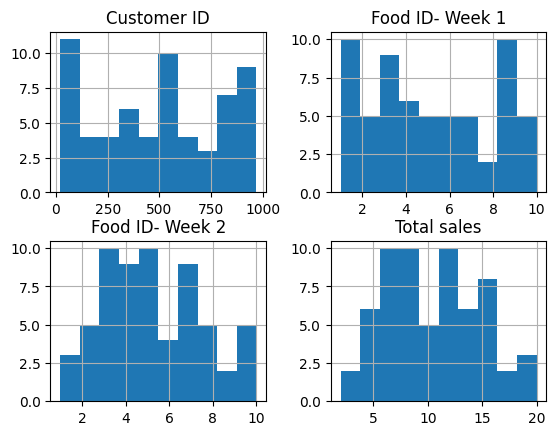

In [37]:
sales = week1.merge(week2, how="inner", on="Customer ID", suffixes = ["- Week 1", "- Week 2"])
sales['Total sales'] = sales['Food ID- Week 1'] + sales['Food ID- Week 2']
sales.sort_values("Total sales", ascending=False).hist()

In [38]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [39]:
week2.head()

,Customer ID,Food ID
0,688,10
1,813,7
2,495,10
3,189,5
4,267,3


In [40]:
week1.merge(week2, how="inner", on=["Customer ID", "Food ID"])

,Customer ID,Food ID
0,304,3
1,540,3
2,937,10
3,233,3
4,21,4
5,21,4
6,922,1
7,578,5
8,578,5


In [42]:
condition_one = week1["Customer ID"] == 304
condition_two = week1["Food ID"] == 3
week1[condition_one & condition_two]


,Customer ID,Food ID
55,304,3


In [43]:
condition_one = week2["Customer ID"] == 304
condition_two = week2["Food ID"] == 3
week1[condition_one & condition_two]


,Customer ID,Food ID
88,937,10


In [45]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [46]:
week2.head()

,Customer ID,Food ID
0,688,10
1,813,7
2,495,10
3,189,5
4,267,3


In [47]:
week1.merge(week2, how= "outer", on="Customer ID")

,Customer ID,Food ID_x,Food ID_y
0,537,9.0,5.0
1,97,4.0,NaN
2,658,1.0,NaN
3,202,2.0,NaN
4,155,9.0,3.0
...,...,...,...
449,855,NaN,4.0
450,559,NaN,10.0
451,276,NaN,4.0
452,556,NaN,10.0


In [48]:
week1.merge(week2, how= "outer", on="Customer ID", indicator=True)

,Customer ID,Food ID_x,Food ID_y,_merge
0,537,9.0,5.0,both
1,97,4.0,NaN,left_only
2,658,1.0,NaN,left_only
3,202,2.0,NaN,left_only
4,155,9.0,3.0,both
...,...,...,...,...
449,855,NaN,4.0,right_only
450,559,NaN,10.0,right_only
451,276,NaN,4.0,right_only
452,556,NaN,10.0,right_only


In [50]:
merge = week1.merge(week2, how= "outer", on="Customer ID", indicator=True)
merge['_merge'].value_counts()

merge[merge['_merge'].isin(["left_only", "right_only"])]

,Customer ID,Food ID_x,Food ID_y,_merge
1,97,4.0,NaN,left_only
2,658,1.0,NaN,left_only
3,202,2.0,NaN,left_only
6,213,8.0,NaN,left_only
7,600,1.0,NaN,left_only
...,...,...,...,...
449,855,NaN,4.0,right_only
450,559,NaN,10.0,right_only
451,276,NaN,4.0,right_only
452,556,NaN,10.0,right_only


In [1]:
import pandas as pd

food = pd.read_csv("Restaurant - Foods.csv", index_col="Food ID")
customers = pd.read_csv("Restaurant - Customers.csv", index_col= "ID")
week1 = pd.read_csv("Restaurant - Week 1 Sales.csv")
week2 = pd.read_csv("Restaurant - Week 2 Sales.csv")


In [7]:
week1.merge(customers, how='left', left_on="Customer ID", right_index=True)

,Customer ID,Food ID,First Name,Last Name,Gender,Company,Occupation
0,537,9,Cheryl,Carroll,Female,Zoombeat,Registered Nurse
1,97,4,Amanda,Watkins,Female,Ozu,Account Coordinator
2,658,1,Patrick,Webb,Male,Browsebug,Community Outreach Specialist
3,202,2,Louis,Campbell,Male,Rhynoodle,Account Representative III
4,155,9,Carolyn,Diaz,Female,Gigazoom,Database Administrator III
...,...,...,...,...,...,...,...
245,413,9,Diane,Bailey,Female,Wikibox,Technical Writer
246,926,6,Anne,Wagner,Female,Skyba,Legal Assistant
247,134,3,Diana,Hall,Female,Quinu,Financial Advisor
248,396,6,Juan,Romero,Male,Zoonder,Analyst Programmer


In [8]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [9]:
customers.head()

,First Name,Last Name,Gender,Company,Occupation
ID,,,,,
1,Joseph,Perkins,Male,Dynazzy,Community Outreach Specialist
2,Jennifer,Alvarez,Female,DabZ,Senior Quality Engineer
3,Roger,Black,Male,Tagfeed,Account Executive
4,Steven,Evans,Male,Fatz,Registered Nurse
5,Judy,Morrison,Female,Demivee,Legal Assistant


In [10]:
food.head()

,Food Item,Price
Food ID,,
1,Sushi,3.99
2,Burrito,9.99
3,Taco,2.99
4,Quesadilla,4.25
5,Pizza,2.49


In [6]:
week1.merge(
    customers, how='left', left_on="Customer ID", right_index=True
    ).merge(food, how="left", left_on="Food ID", right_index=True)

,Customer ID,Food ID,First Name,Last Name,Gender,Company,Occupation,Food Item,Price
0,537,9,Cheryl,Carroll,Female,Zoombeat,Registered Nurse,Donut,0.99
1,97,4,Amanda,Watkins,Female,Ozu,Account Coordinator,Quesadilla,4.25
2,658,1,Patrick,Webb,Male,Browsebug,Community Outreach Specialist,Sushi,3.99
3,202,2,Louis,Campbell,Male,Rhynoodle,Account Representative III,Burrito,9.99
4,155,9,Carolyn,Diaz,Female,Gigazoom,Database Administrator III,Donut,0.99
...,...,...,...,...,...,...,...,...,...
245,413,9,Diane,Bailey,Female,Wikibox,Technical Writer,Donut,0.99
246,926,6,Anne,Wagner,Female,Skyba,Legal Assistant,Pasta,13.99
247,134,3,Diana,Hall,Female,Quinu,Financial Advisor,Taco,2.99
248,396,6,Juan,Romero,Male,Zoonder,Analyst Programmer,Pasta,13.99
